In [1]:
from src import *
from myutils import *

import gc

In [2]:
class v_sim(Simulator):
    def loc(self, n):
        fs = self.sampling_rate
        t = n / fs
        return 400 * t - 5 * DMD.PIXEL_SIZE

In [3]:
# Fisher Info Mat

fi11 = 1/(SPADE.SIGMA*20)**2 * np.sum(np.arange(10)**2)
fi12 = 1/(SPADE.SIGMA*20)**2 * np.sum(np.arange(10)**1)
fi22 = 1/(SPADE.SIGMA*20)**2 * np.sum(np.arange(10)**0)
crb = np.linalg.inv(np.array([[fi11, fi12], [fi12, fi22]]))[0, 0]

In [4]:
class VelocityEstimation:
    @classmethod
    def FromRaw(cls, raw: np.ndarray, metadata: MetaData):
        if metadata.measurement.upper() == 'SPADE':
            expt = SPADE(raw, velocity=True)
        elif metadata.measurement.upper() == 'DI':
            expt = DI(raw, velocity=True)
        else:
            raise ValueError
        
        del raw

        # gc.collect()
        expt.est_all(metadata)
        return expt.estimates


    # @classmethod
    # def FromEstimates(cls, Estimates_instance: Estimates):
    #     c: Estimates = np.copy(Estimates_instance).item()
    #     del Estimates_instance

    #     if c.metadata.measurement.upper() == 'SPADE':
    #         expt = SPADE(cropped=c.cropped_data, noise=c.noise)
    #     elif c.metadata.measurement.upper() == 'DI':
    #         expt = DI(amplitude=c.metadata.amplitude, cropped=c.cropped_data, noise=c.noise)
    #     else:
    #         raise ValueError

    #     gc.collect()
    #     expt.est_all(c.metadata)
    #     return expt.estimates

In [5]:
meta = MetaData('SPADE', 400.0, timestamp=np.load(r'f:\20241121\spade_v\spade_v400.0_d0_timestamp.npy'))
raw = np.load(r'f:\20241121\spade_v\spade_v400.0_d0_raw.npy')

In [5]:
meta = MetaData('DI', 400.0, timestamp=np.load(r'/Volumes/nvmeOFwiz/20241121/di_v/di_v400.0_d0_timestamp.npy'))
raw = np.load(r'/Volumes/nvmeOFwiz/20241121/di_v/di_v400.0_d0_raw.npy')

In [6]:
c = VelocityEstimation.FromRaw(raw, meta)

In [7]:
c.velocity_estimates

array([1.67566628, 1.6665151 , 1.63208661, 1.58122132, 1.6294509 ,
       1.62792798, 1.52366572, 1.66671795, 1.68361853, 1.58215995,
       1.68174368, 1.4348243 , 1.62967355, 1.59203739, 1.68408491,
       1.78699266, 1.50574656, 1.55807031, 1.64553212, 1.51088756,
       1.53806371, 1.53524556, 1.71517571, 1.61963298, 1.6131496 ,
       1.66764011, 1.79470657, 1.64853306, 1.51587324, 1.57884537,
       1.73334541, 1.66538971, 1.64050823, 1.57817932, 1.5647396 ,
       1.64794477, 1.63950117, 1.67790989, 1.52425993, 1.69456855,
       1.61023849, 1.50491042, 1.65529514, 1.57933169, 1.67859044,
       1.55854257, 1.64935146, 1.59647095, 1.68808879, 1.57375238,
       1.63358069, 1.60508836, 1.55230043, 1.45622906, 1.73196607,
       1.59703055, 1.55159157, 1.49540492, 1.56399861, 1.60360479,
       1.62034895, 1.69436226, 1.64794299, 1.66579233, 1.68916447,
       1.69074342, 1.68951724, 1.61170019, 1.68967691, 1.5627225 ,
       1.53816743, 1.70020318, 1.62761414, 1.61844537, 1.50512

In [7]:
400 * (0.05 * 10)

200.0

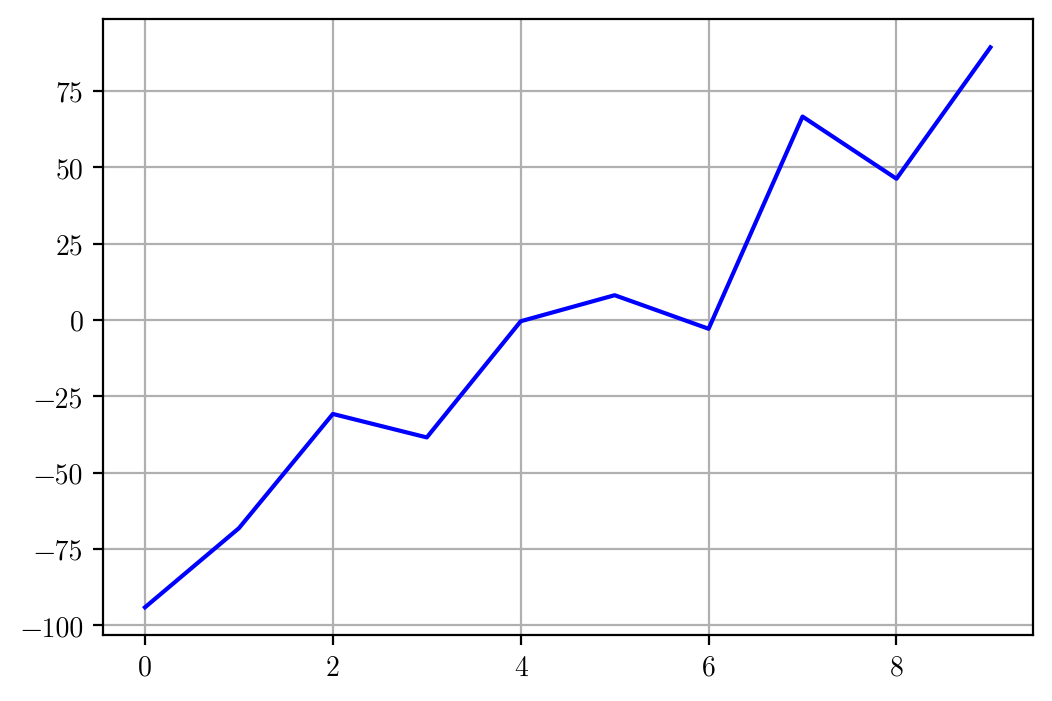

In [8]:
plot(c.time_domain[1])

In [17]:
c.velocity_estimates.mean()

391.9625439603831

In [9]:
10 * DMD.PIXEL_SIZE / qCMOS.PIXEL_SIZE

42.118969140242186

In [10]:
int((DMD.PIXEL_SIZE / 400) * 1e6)

48436

In [11]:
DMD.PIXEL_SIZE / 48436e-6

400.00672649499137

In [12]:
c.velocity_estimates

array([450.21046553, 370.07020802, 380.53450997, 422.12295167,
       354.61659389, 349.28651832, 328.57545253, 411.65340051,
       350.29737909, 384.37927129, 365.18977613, 365.71213873,
       400.55175836, 394.43443607, 414.91594971, 395.65304346,
       433.34532643, 402.53586036, 325.51506358, 444.63852909,
       361.87066691, 386.81923335, 387.00523521, 337.7932928 ,
       438.92818577, 350.2489479 , 389.24541863, 408.60575   ,
       436.13667986, 447.65963355, 445.80217675, 417.40020084,
       416.20445361, 367.36005995, 393.3485448 , 365.15413472,
       381.4967083 , 400.01199675, 376.17727199, 406.26507261,
       337.96885168, 338.74919929, 366.62098605, 383.46114326,
       334.00498568, 399.35665108, 411.00944389, 399.53702249,
       433.01286908, 363.60893357, 428.77638635, 365.04013171,
       337.08810857, 393.49007305, 366.77443751, 409.99738345,
       362.54531488, 360.26695853, 348.76740611, 365.90758823,
       396.39815235, 315.65225815, 374.71319641, 486.19

In [13]:
0.05 * np.arange(10)

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45])

In [14]:
(0.45 * 400) / qCMOS.PIXEL_SIZE

39.130434782608695

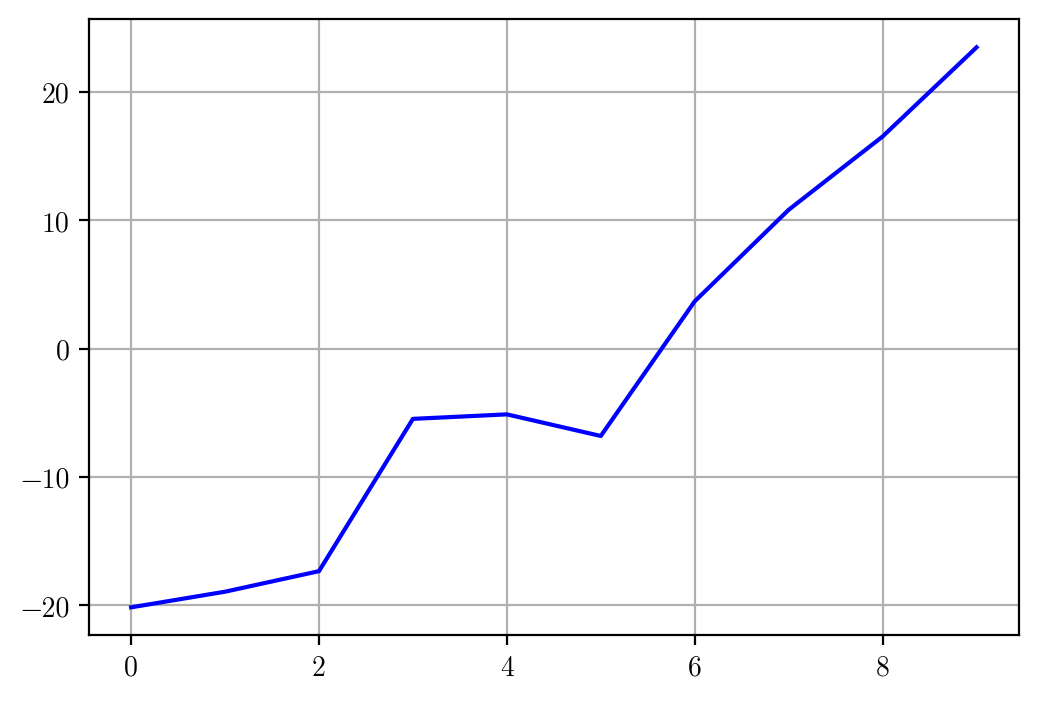

In [15]:
plot(c.time_domain[0] / qCMOS.PIXEL_SIZE)